# Phase 1: MetroPT-3 Exploratory Data Analysis and Labeling

**Goal:** understand the data, plot the sensors, add the failure windows, and create labels for the later ML phases.

**Expected folder layout**
```
metropt/
├── data/raw/          <- put the downloaded CSV here
├── data/processed/    <- outputs of this notebook
└── notebooks/01_eda.ipynb   <- this file
```
Install once: `pip install pandas pyarrow matplotlib seaborn jupyter`

## 0. Imports and config

In [1]:
import glob, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RAW_DIR = Path("../data/raw")
PROC_DIR = Path("../data/processed")
PROC_DIR.mkdir(parents=True, exist_ok=True)

ANALOG = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
DIGITAL = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

## 1. Load the data

In [2]:
csv_files = glob.glob(str(RAW_DIR / "*.csv"))
print("CSV files found:", csv_files)
assert csv_files, "No CSV found in data/raw/ - copy the MetroPT-3 CSV there first."

df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
df.head()

CSV files found: ['..\\data\\raw\\MetroPT3(AirCompressor).csv']
Shape: (1516948, 17)


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 2. Clean, parse timestamps, cache as parquet

In [3]:
# Drop a leftover index column if the CSV has one
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")])

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")

print("Columns:", list(df.columns))
missing_cols = [c for c in ANALOG + DIGITAL if c not in df.columns]
print("Expected columns missing from file:", missing_cols)

df.to_parquet(PROC_DIR / "metropt3.parquet")
print("Saved parquet (much faster to reload next time).")

Columns: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']
Expected columns missing from file: []
Saved parquet (much faster to reload next time).


## 3. Sanity checks

In [4]:
df.info()
print()
print("Time range:", df.index.min(), "->", df.index.max())
print("Monotonic increasing:", df.index.is_monotonic_increasing)
print("Duplicate timestamps:", df.index.duplicated().sum())
print()
print("Missing values per column:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 1516948 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Data columns (total 15 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   TP2              1516948 non-null  float64
 1   TP3              1516948 non-null  float64
 2   H1               1516948 non-null  float64
 3   DV_pressure      1516948 non-null  float64
 4   Reservoirs       1516948 non-null  float64
 5   Oil_temperature  1516948 non-null  float64
 6   Motor_current    1516948 non-null  float64
 7   COMP             1516948 non-null  float64
 8   DV_eletric       1516948 non-null  float64
 9   Towers           1516948 non-null  float64
 10  MPG              1516948 non-null  float64
 11  LPS              1516948 non-null  float64
 12  Pressure_switch  1516948 non-null  float64
 13  Oil_level        1516948 non-null  float64
 14  Caudal_impulses  1516948 non-null  float64
dtypes: float64(15)
memory usage: 185.2 MB

Time 

### 3.1 Sampling interval and gaps (machine off / data loss)

In [5]:
dt = df.index.to_series().diff()

print("Most common sampling intervals:")
print(dt.value_counts().head())
print()
print("10 largest gaps:")
print(dt.nlargest(10))

Most common sampling intervals:
timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
Name: count, dtype: int64

10 largest gaps:
timestamp
2020-04-27 01:12:49   2 days 00:01:58
2020-06-28 23:07:43   1 days 12:14:36
2020-03-01 04:00:09   1 days 04:03:01
2020-08-05 08:23:01   1 days 00:40:33
2020-05-25 01:14:14   1 days 00:34:51
2020-07-08 15:20:51   0 days 23:56:00
2020-08-23 18:51:01   0 days 23:39:17
2020-05-10 22:48:58   0 days 22:17:41
2020-06-08 11:48:04   0 days 21:28:25
2020-04-02 09:59:17   0 days 20:43:37
Name: timestamp, dtype: timedelta64[us]


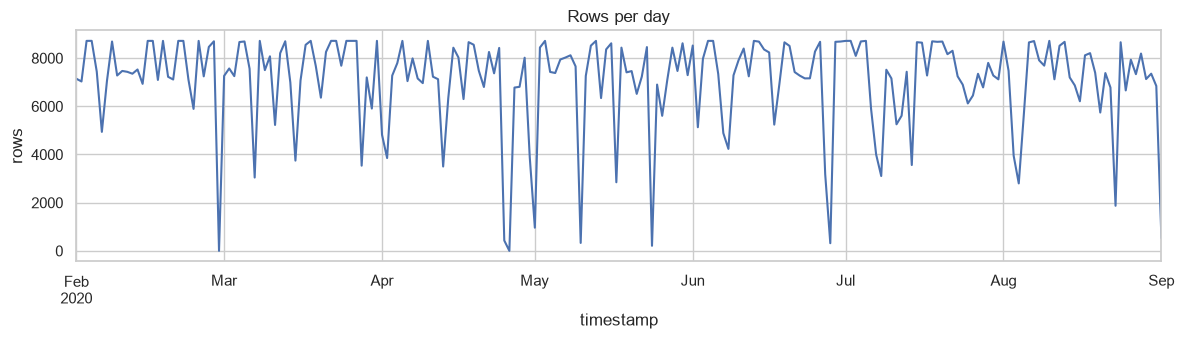

In [6]:
# Rows per day - drops show days the machine was off or data is missing
rows_per_day = df.resample("1D").size()
ax = rows_per_day.plot(figsize=(14, 3), title="Rows per day")
ax.set_ylabel("rows")
plt.show()

### 3.2 Summary statistics

In [7]:
display(df.describe().T)

constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Constant columns:", constant_cols)

print()
print("Unique values in digital columns:")
for c in DIGITAL:
    if c in df.columns:
        print(f"  {c:16s} {sorted(df[c].dropna().unique())[:6]}")

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295
COMP,1516948.0,0.836957,0.369405,0.000,1.000,1.000,1.0000,1.000
DV_eletric,1516948.0,0.160611,0.367172,0.000,0.000,0.000,0.0000,1.000
Towers,1516948.0,0.919848,0.271528,0.000,1.000,1.000,1.0000,1.000


Constant columns: []

Unique values in digital columns:
  COMP             [np.float64(0.0), np.float64(1.0)]
  DV_eletric       [np.float64(0.0), np.float64(1.0)]
  Towers           [np.float64(0.0), np.float64(1.0)]
  MPG              [np.float64(0.0), np.float64(1.0)]
  LPS              [np.float64(0.0), np.float64(1.0)]
  Pressure_switch  [np.float64(0.0), np.float64(1.0)]
  Oil_level        [np.float64(0.0), np.float64(1.0)]
  Caudal_impulses  [np.float64(0.0), np.float64(1.0)]


## 4. Visualize the sensors

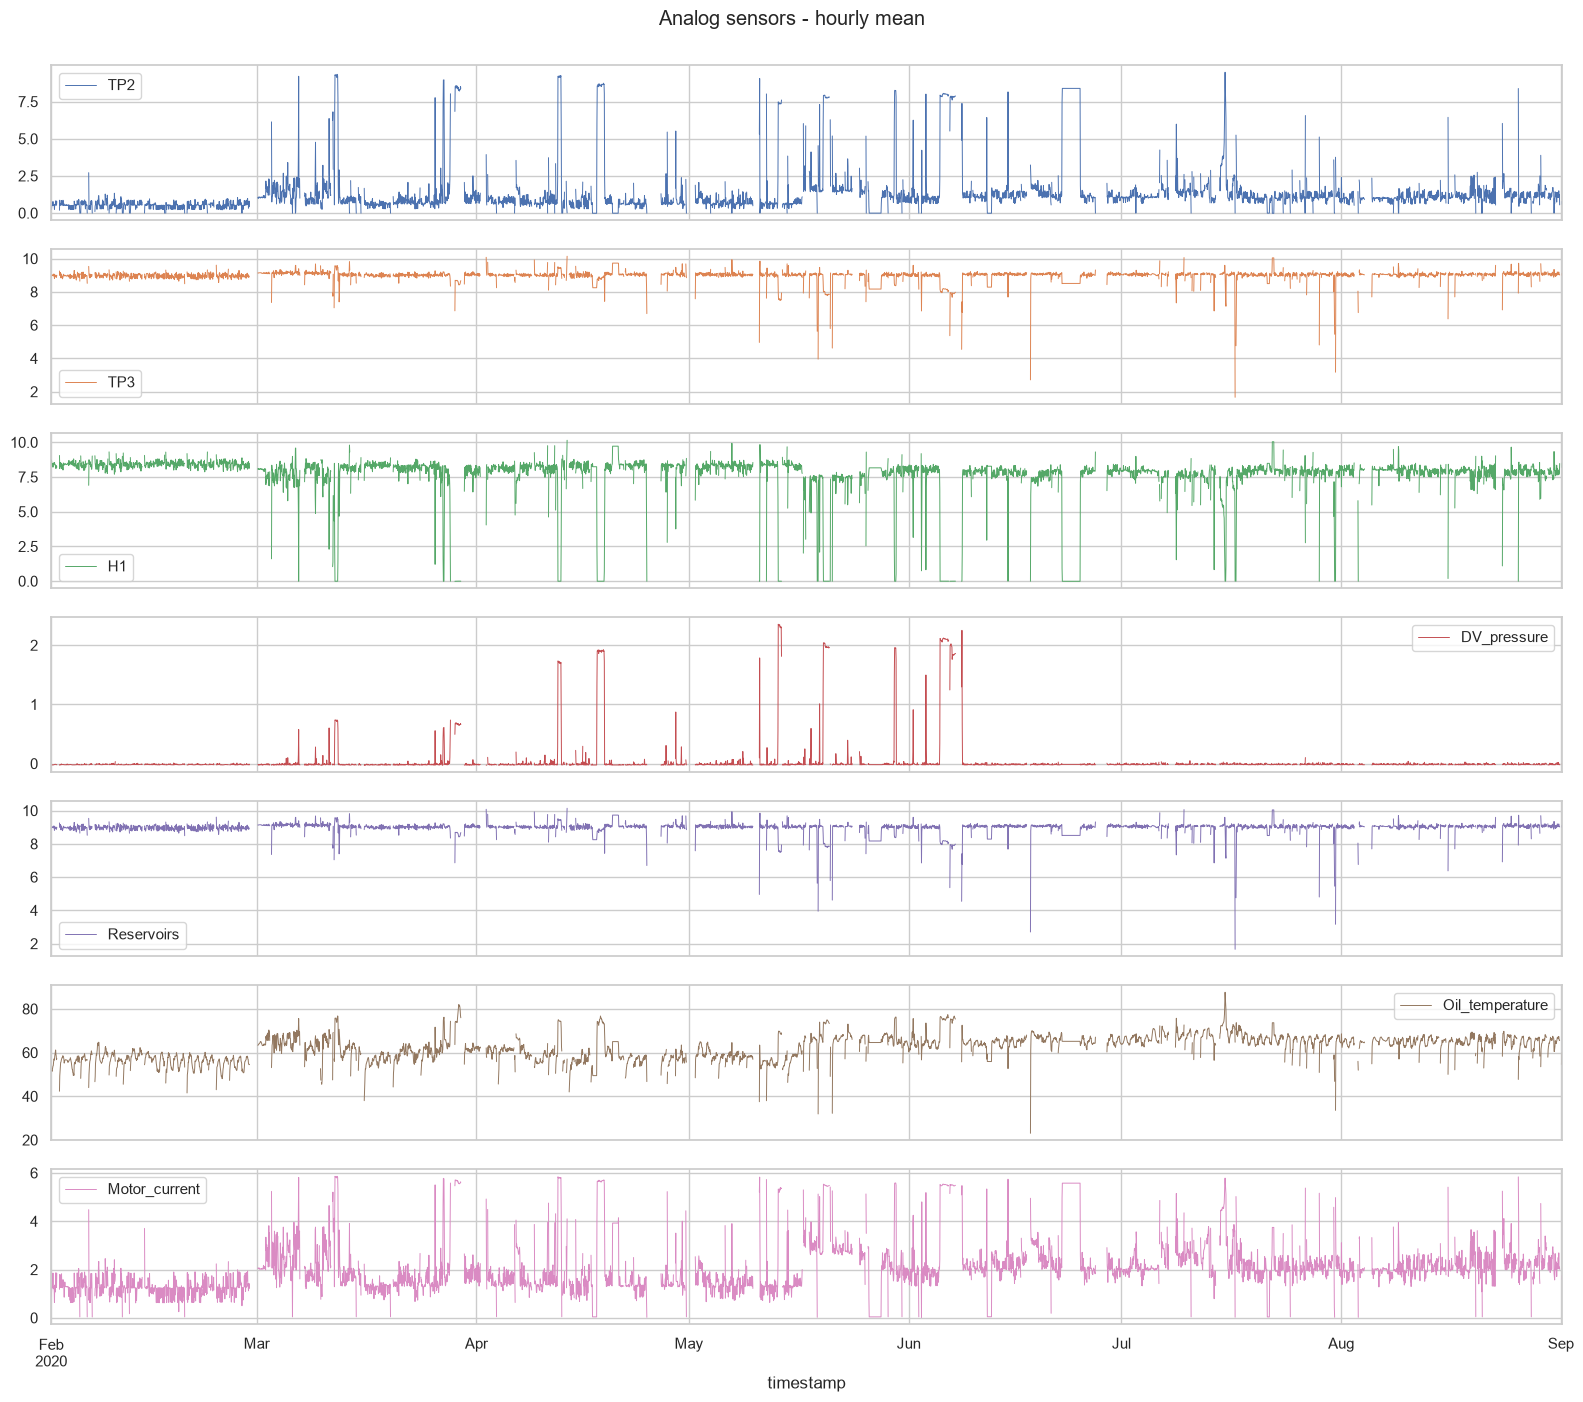

In [8]:
# 1.5M raw rows is too many to plot, so resample to hourly means
hourly = df[ANALOG].resample("1h").mean()

hourly.plot(subplots=True, figsize=(16, 14), sharex=True, lw=0.7,
            title=[""] * len(ANALOG))
plt.suptitle("Analog sensors - hourly mean", y=1.0)
plt.tight_layout()
plt.show()

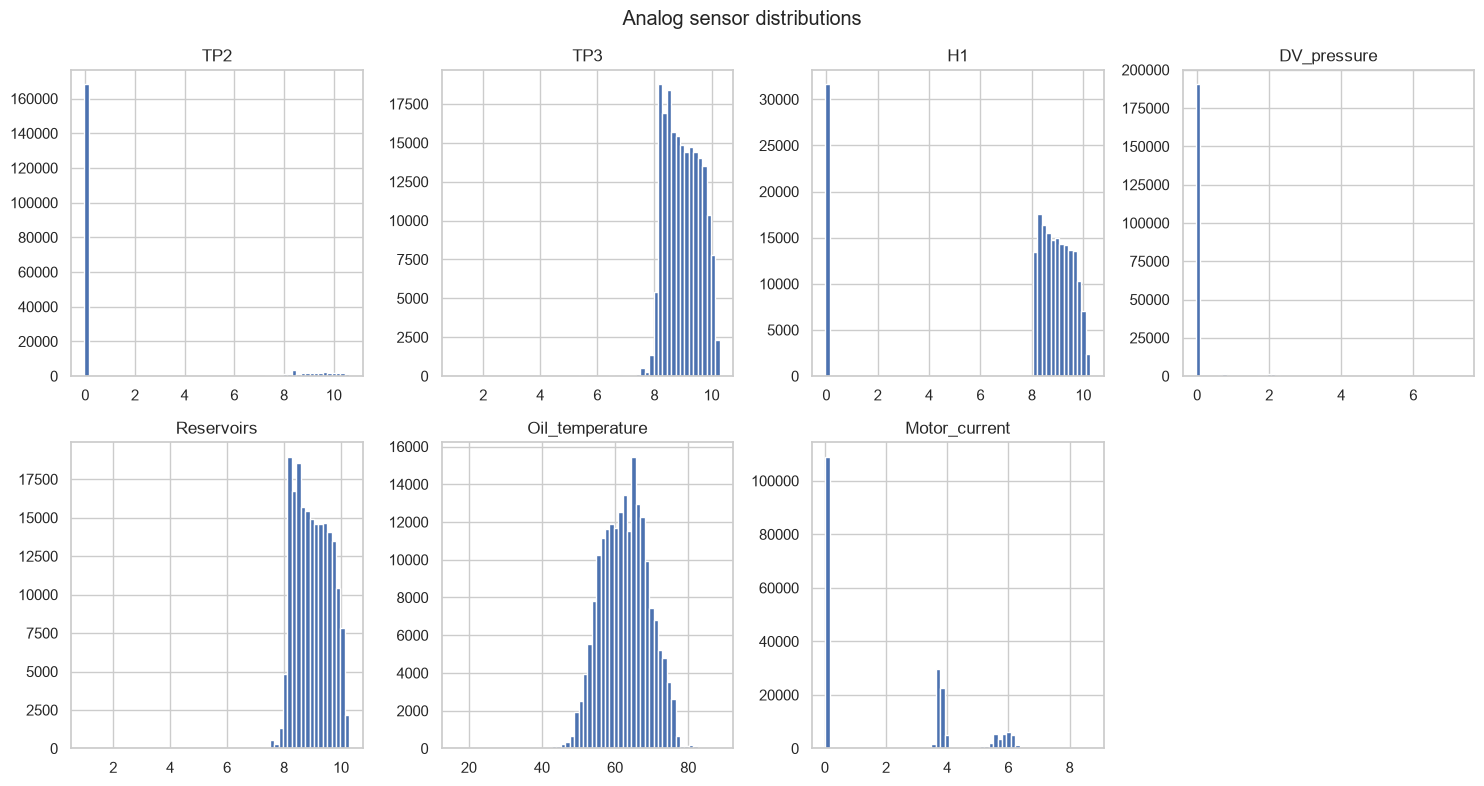

In [9]:
# Distributions of the analog sensors (sampled for speed)
sample = df[ANALOG].sample(min(200_000, len(df)), random_state=42)
sample.hist(bins=60, figsize=(15, 8), layout=(2, 4))
plt.suptitle("Analog sensor distributions")
plt.tight_layout()
plt.show()

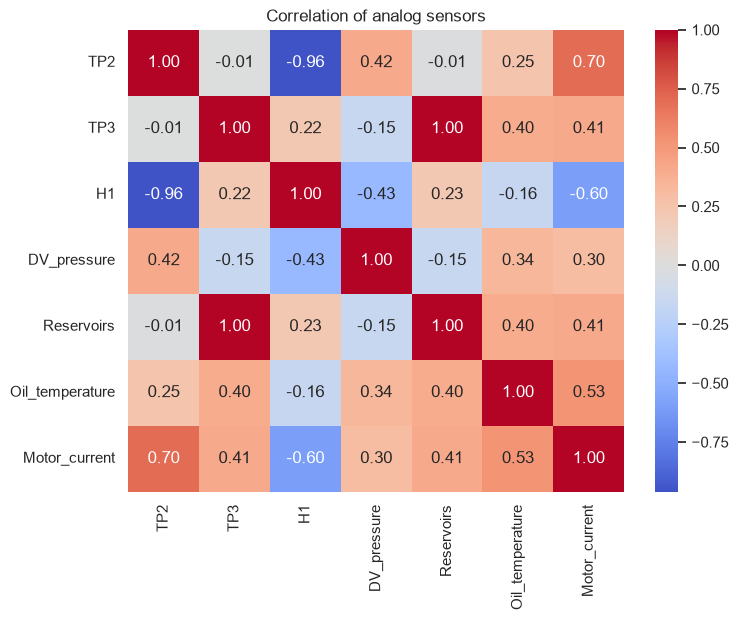

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[ANALOG].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of analog sensors")
plt.show()

### 4.1 Zoom into a few hours of raw data: the compressor on/off cycle

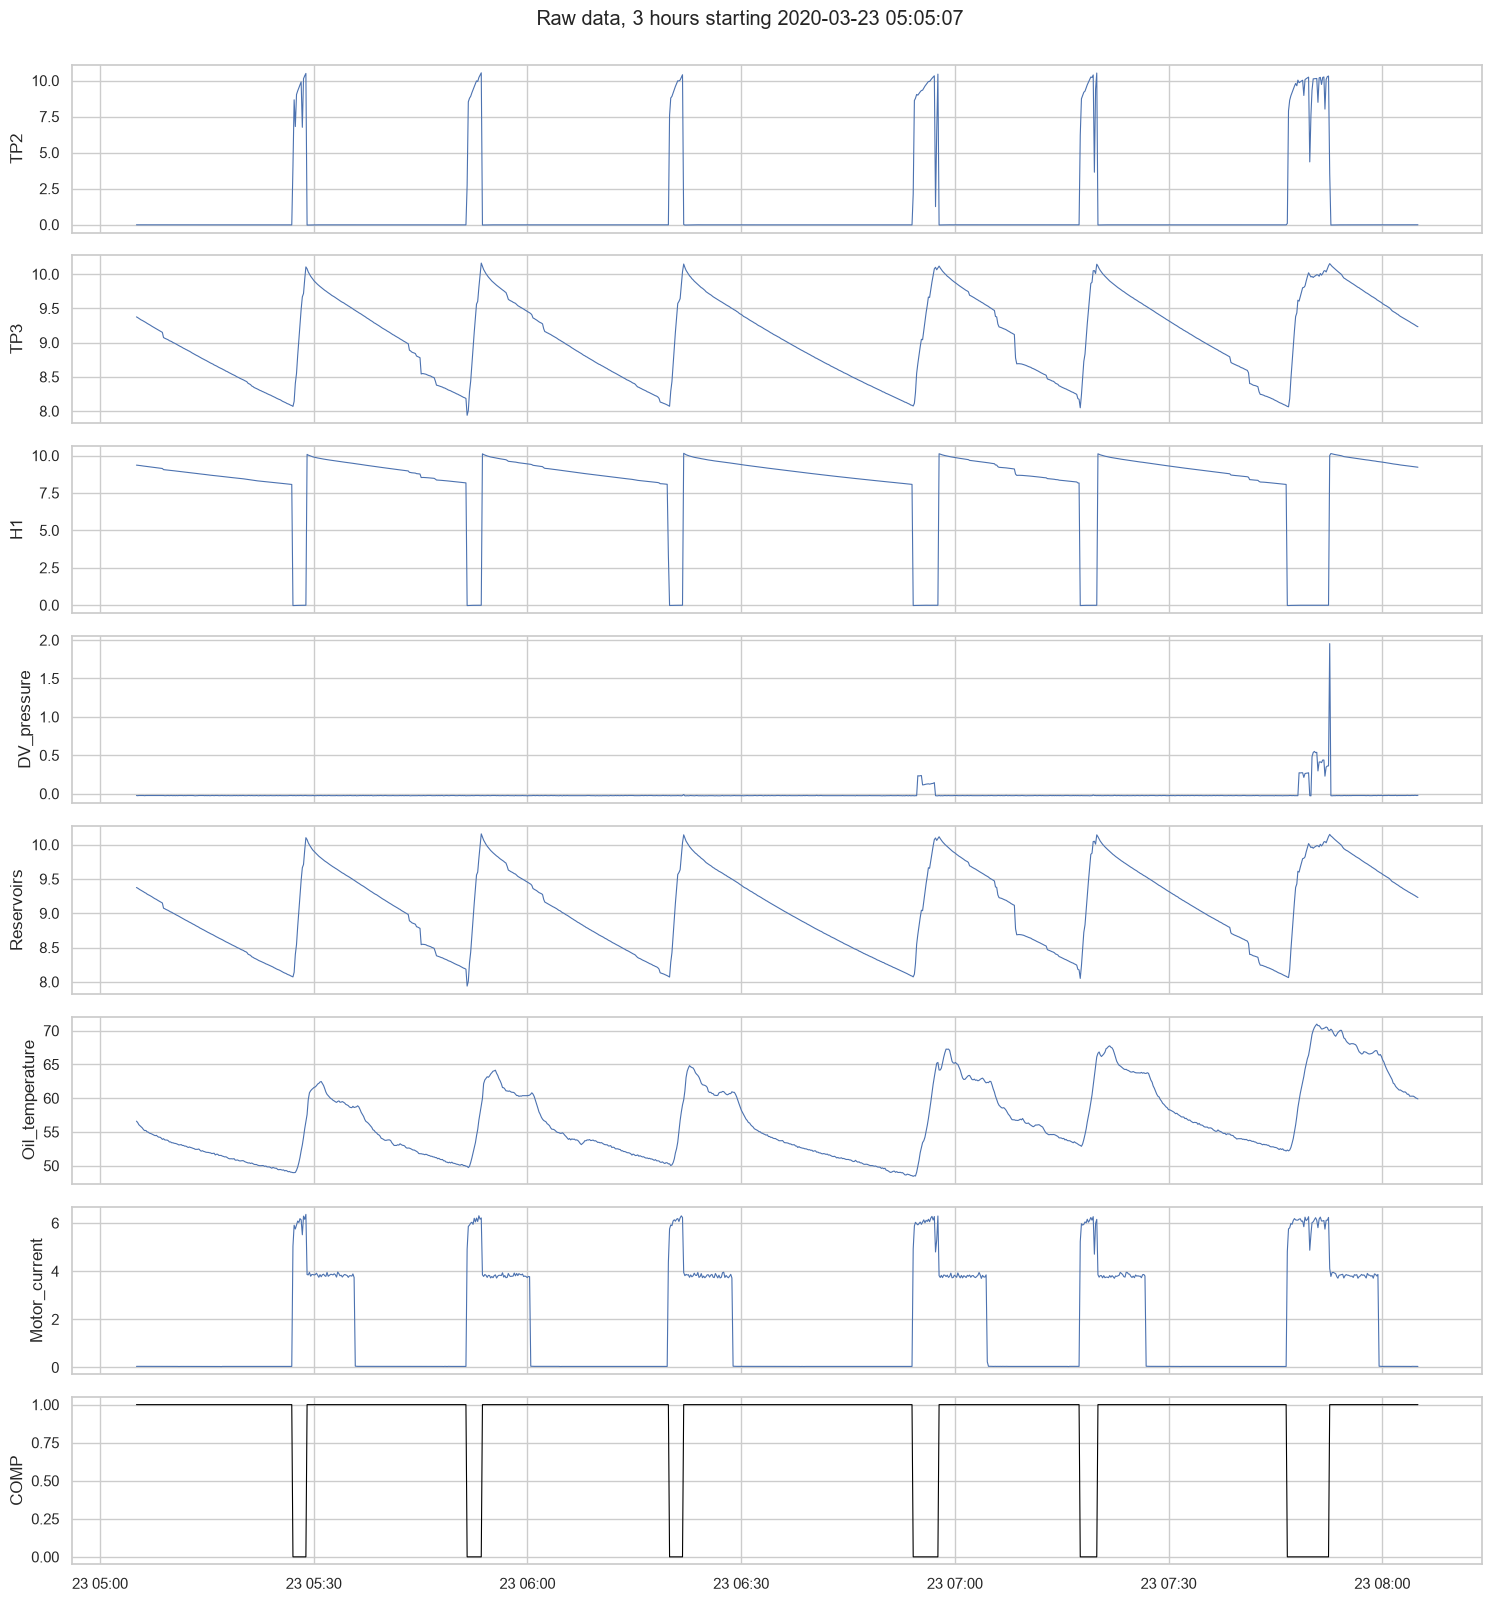

In [11]:
# A compressor loads/unloads repeatedly, so a spike is not automatically an anomaly.
mid = df.index[len(df) // 4]
zoom = df.loc[mid : mid + pd.Timedelta("3h")]

fig, axes = plt.subplots(len(ANALOG) + 1, 1, figsize=(15, 16), sharex=True)
for ax, col in zip(axes, ANALOG):
    ax.plot(zoom.index, zoom[col], lw=0.8)
    ax.set_ylabel(col)
axes[-1].plot(zoom.index, zoom["COMP"], lw=0.8, color="black")
axes[-1].set_ylabel("COMP")
plt.suptitle(f"Raw data, 3 hours starting {mid}", y=1.0)
plt.tight_layout()
plt.show()

## 5. Failure windows

These are the 4 air-leak failures from the MetroPT-3 documentation.
**Verify them against the UCI dataset page / the dataset paper before relying on them.**

In [12]:
FAILURES = [
    ("2020-04-18 00:00", "2020-04-18 23:59"),
    ("2020-05-29 23:30", "2020-05-30 06:00"),
    ("2020-06-05 10:00", "2020-06-07 14:30"),
    ("2020-07-15 14:30", "2020-07-15 19:00"),
]
failures = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in FAILURES]

# Single source of truth for later phases (models, API, dashboard)
with open(PROC_DIR / "failures.json", "w") as f:
    json.dump([{"start": s, "end": e} for s, e in FAILURES], f, indent=2)

for i, (s, e) in enumerate(failures, 1):
    print(f"Failure {i}: {s}  ->  {e}   (duration {e - s})")

Failure 1: 2020-04-18 00:00:00  ->  2020-04-18 23:59:00   (duration 0 days 23:59:00)
Failure 2: 2020-05-29 23:30:00  ->  2020-05-30 06:00:00   (duration 0 days 06:30:00)
Failure 3: 2020-06-05 10:00:00  ->  2020-06-07 14:30:00   (duration 2 days 04:30:00)
Failure 4: 2020-07-15 14:30:00  ->  2020-07-15 19:00:00   (duration 0 days 04:30:00)


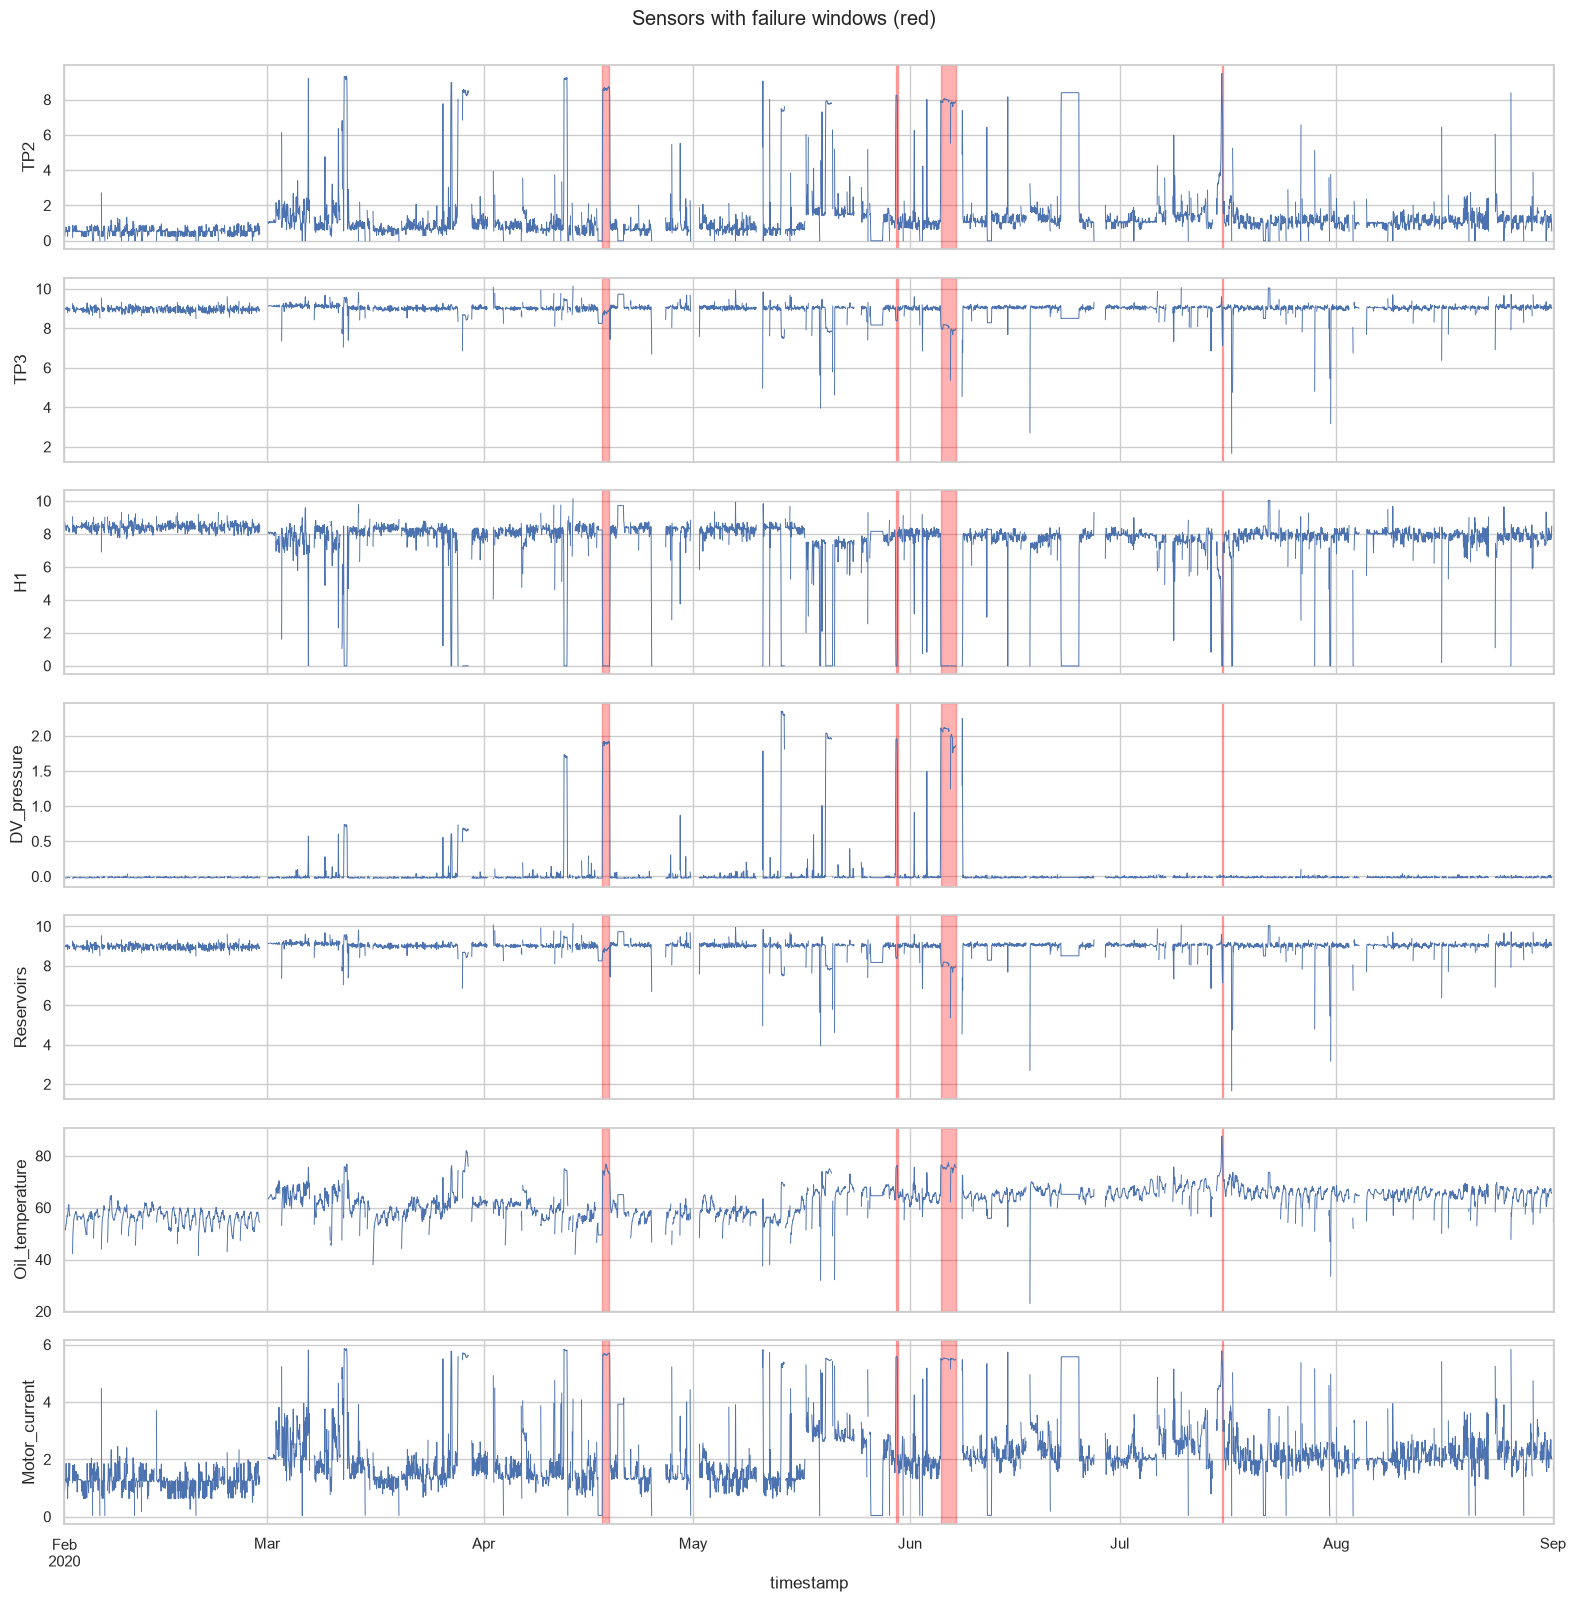

In [13]:
fig, axes = plt.subplots(len(ANALOG), 1, figsize=(16, 16), sharex=True)
for ax, col in zip(axes, ANALOG):
    hourly[col].plot(ax=ax, lw=0.7)
    ax.set_ylabel(col)
    for s, e in failures:
        ax.axvspan(s, e, color="red", alpha=0.3)
plt.suptitle("Sensors with failure windows (red)", y=1.0)
plt.tight_layout()
plt.show()

## 6. Create labels

In [17]:
# a) Failure label: 1 while a failure is happening
df["is_failure"] = 0
for s, e in failures:
    df.loc[s:e, "is_failure"] = 1

# b) Pre-failure label: 1 during the HORIZON before a failure starts
#    (this is the target for the failure-prediction model; try 2h, 6h, 12h, 24h)
HORIZON = pd.Timedelta("6h")
df["fail_within_h"] = 0
for s, e in failures:
    df.loc[s - HORIZON : s, "fail_within_h"] = 1

print("Share of rows labeled 1:")
print(df[["is_failure", "fail_within_h"]].mean().round(5))
print()
print("Row counts:")
print(df[["is_failure", "fail_within_h"]].apply(pd.Series.value_counts))

Share of rows labeled 1:
is_failure       0.01975
fail_within_h    0.00549
dtype: float64

Row counts:
   is_failure  fail_within_h
0     1486994        1508620
1       29954           8328


## 7. Before / during / after each failure

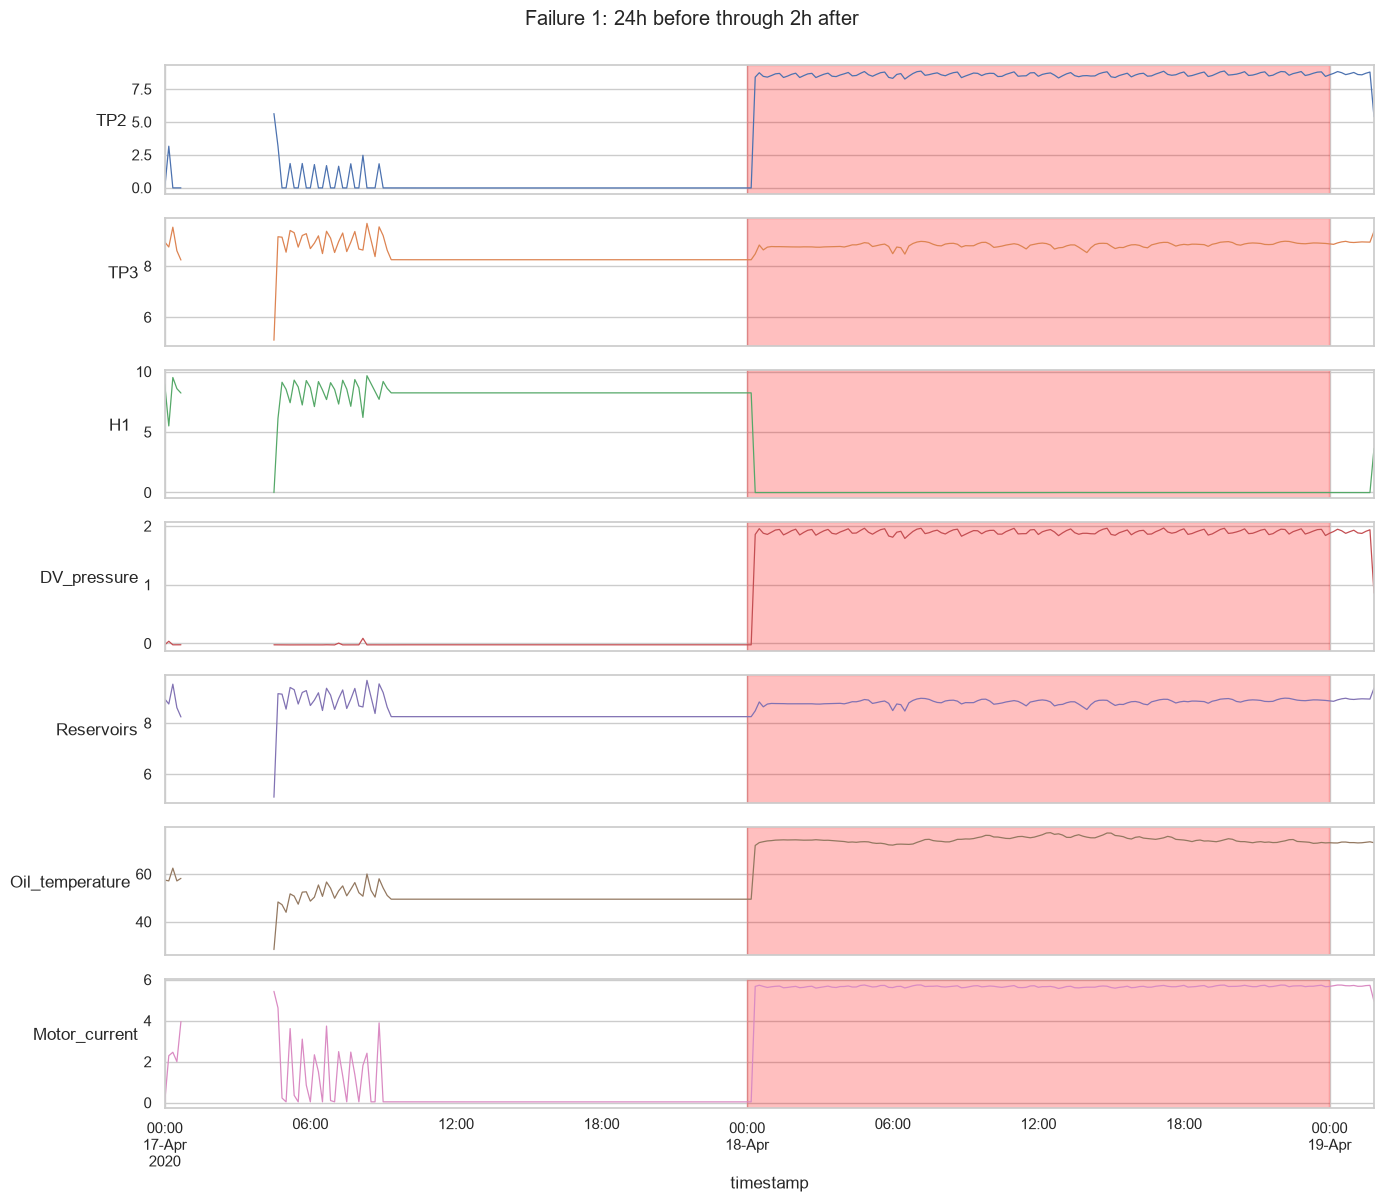

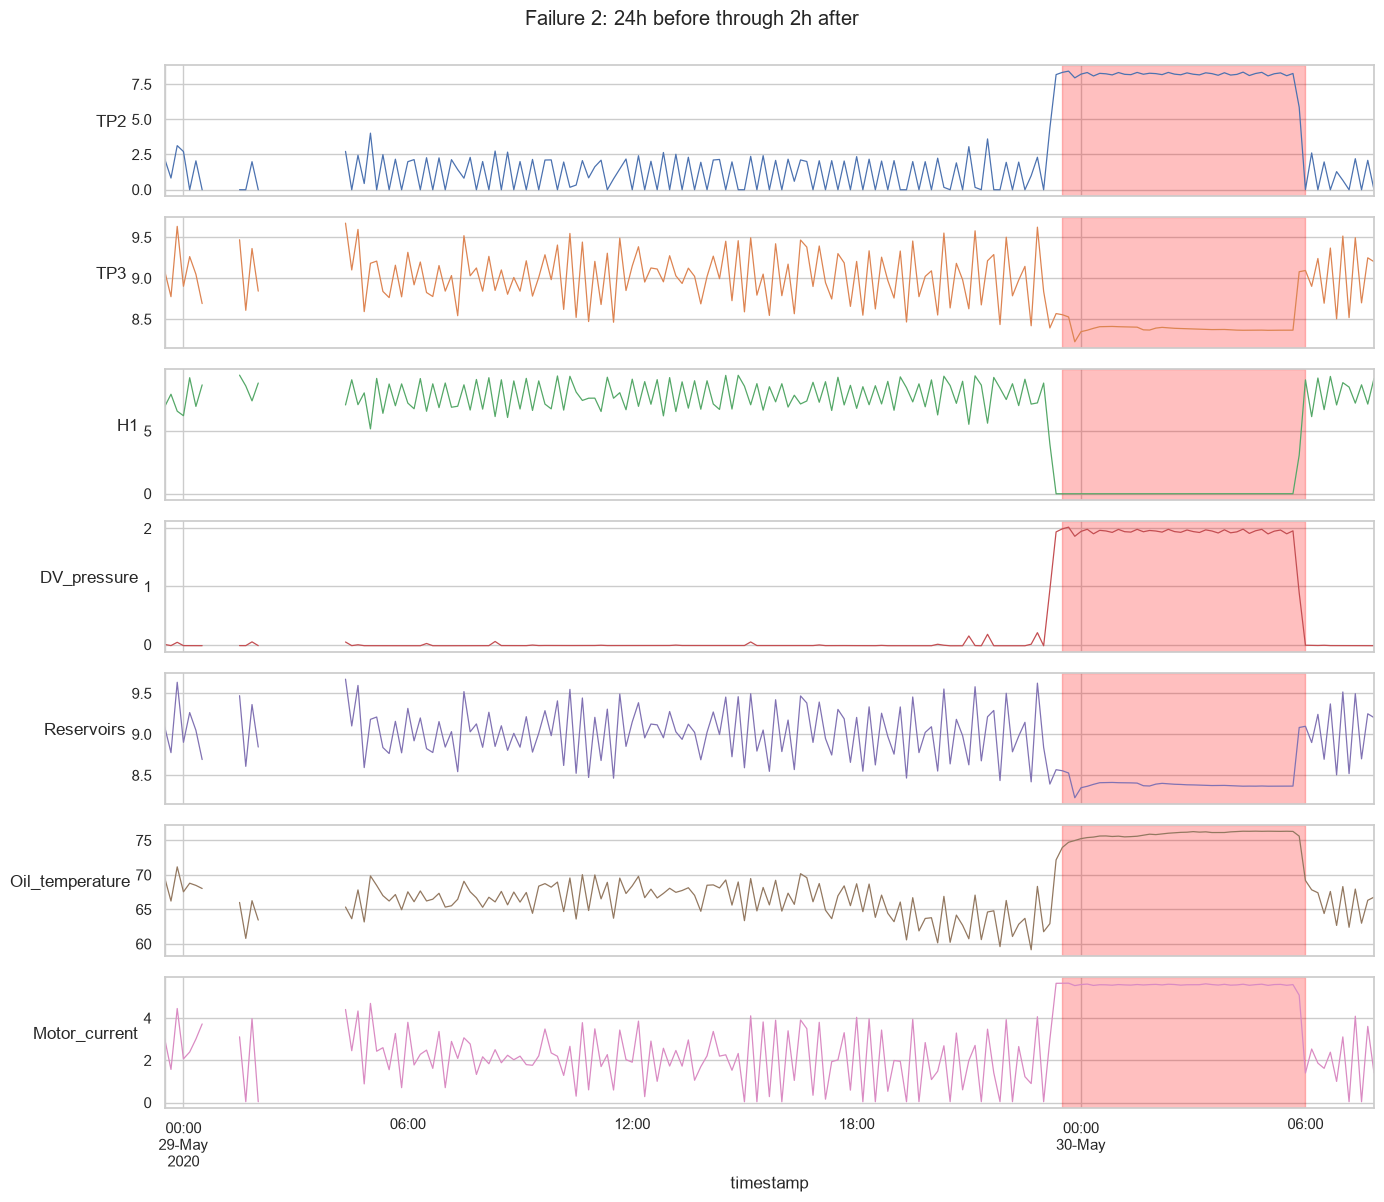

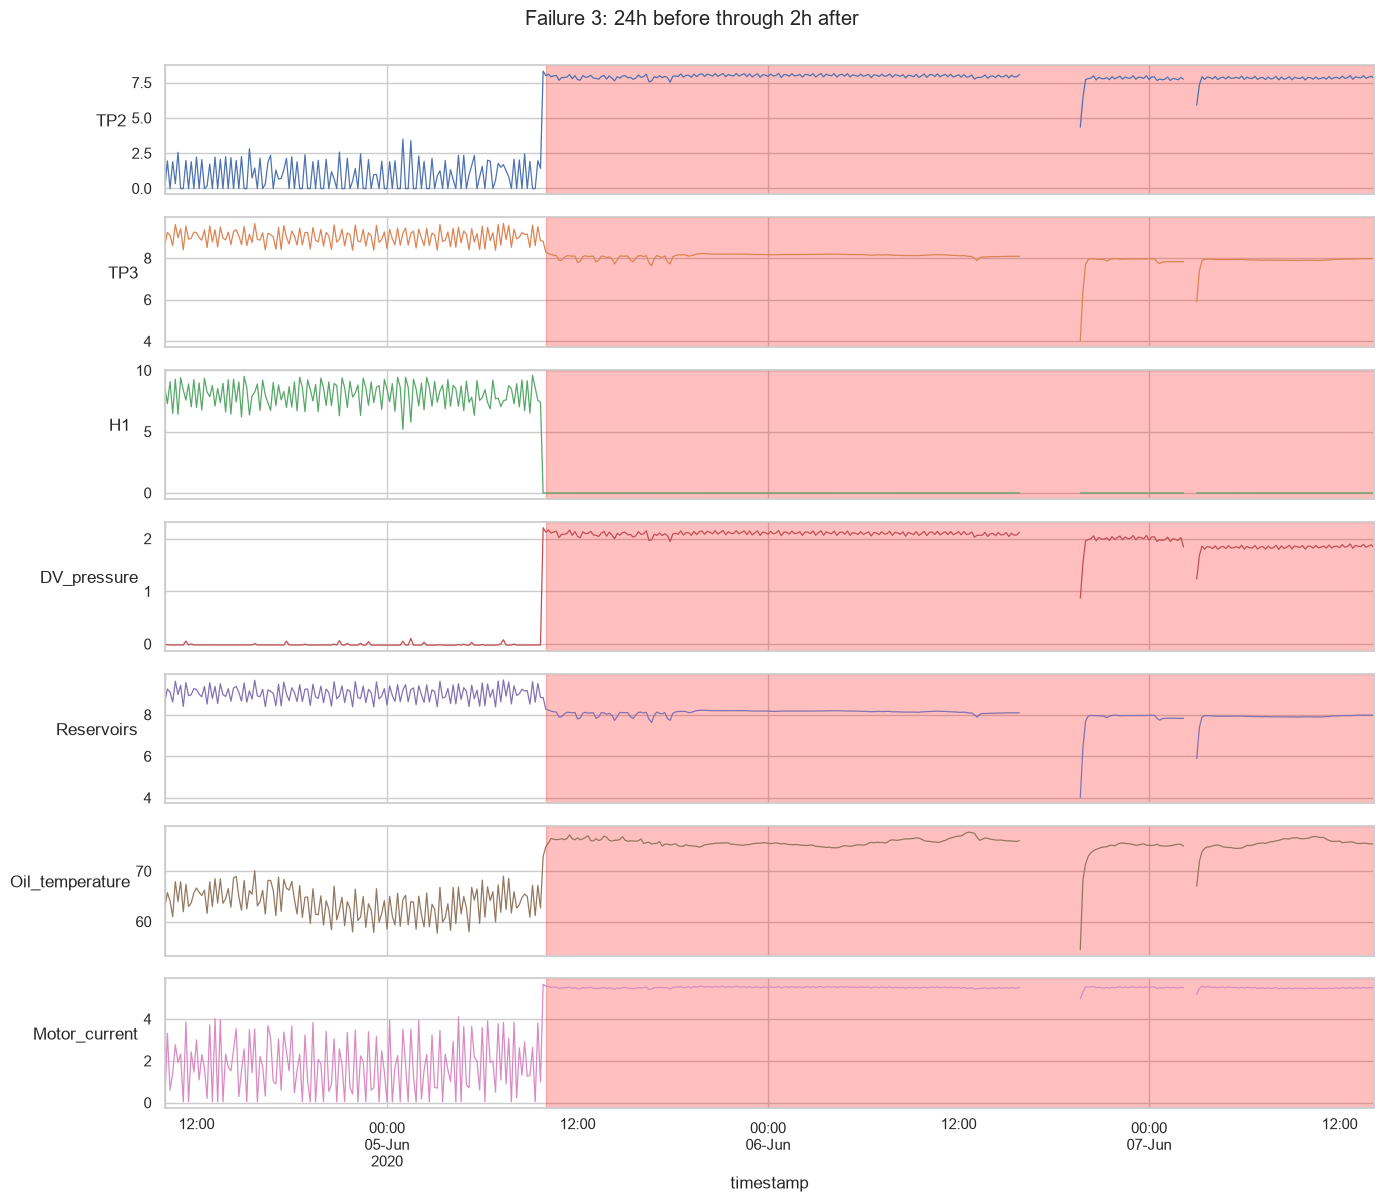

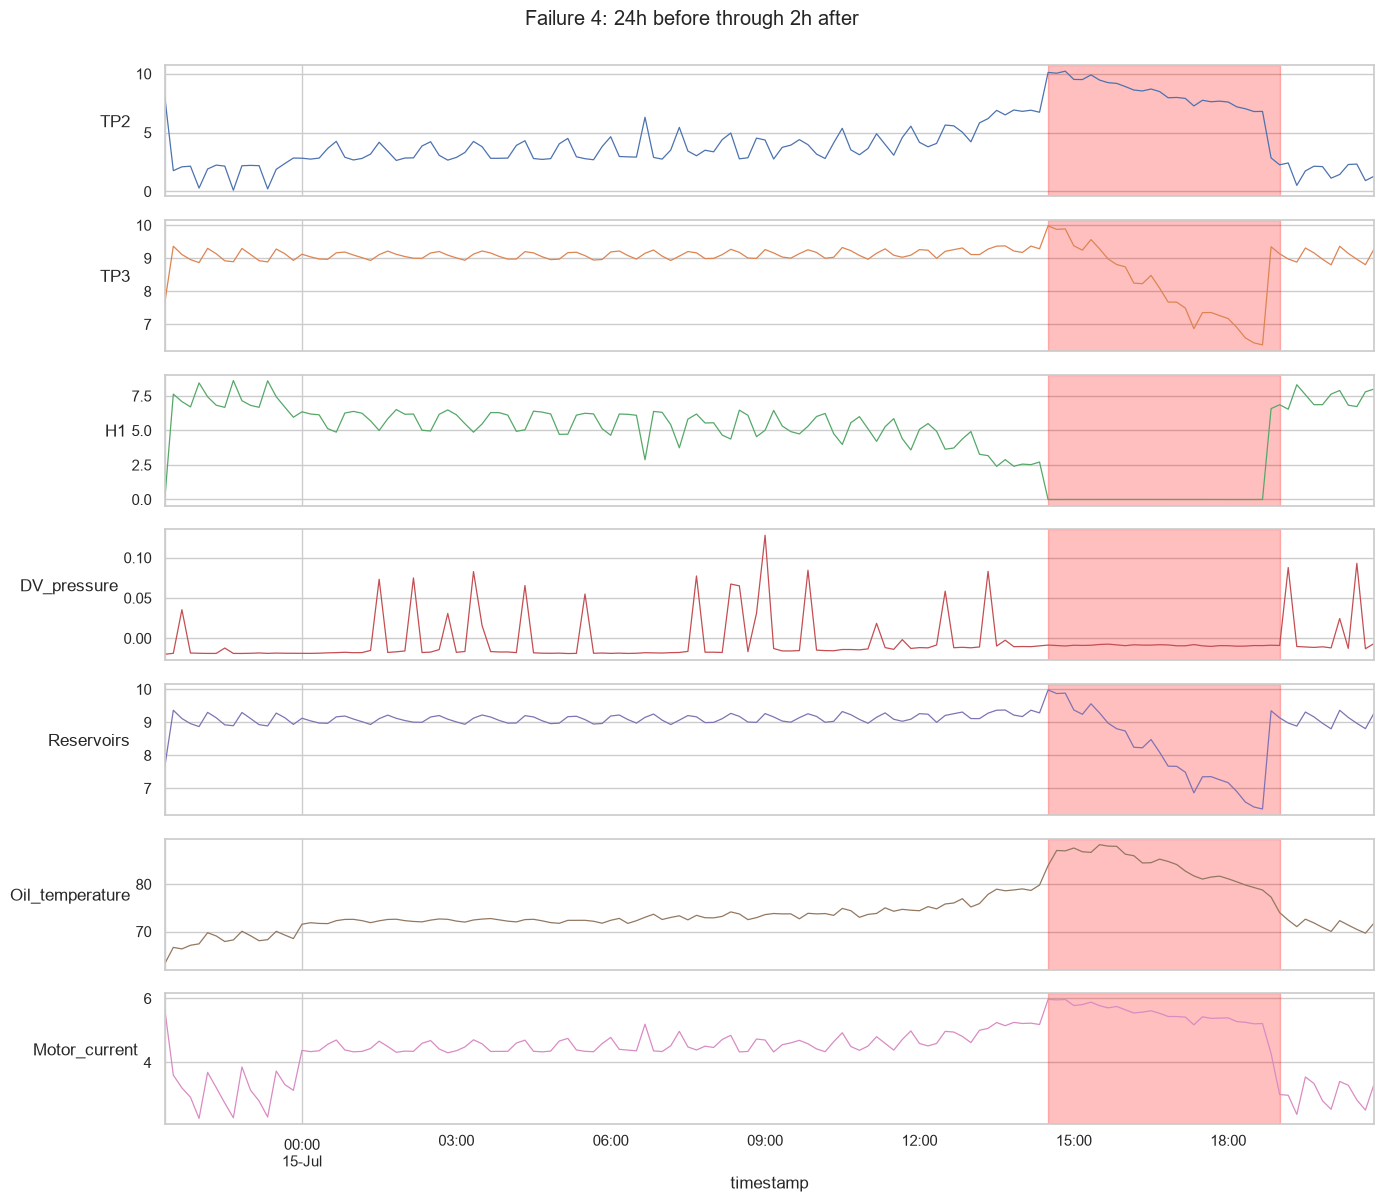

In [18]:
for i, (s, e) in enumerate(failures, 1):
    win = df.loc[s - pd.Timedelta("24h") : e + pd.Timedelta("2h"), ANALOG]
    win = win.resample("10min").mean()
    axes = win.plot(subplots=True, figsize=(14, 12), sharex=True, lw=0.9, legend=False)
    for ax, col in zip(axes, ANALOG):
        ax.set_ylabel(col, rotation=0, ha="right")
        ax.axvspan(s, e, color="red", alpha=0.25)
    plt.suptitle(f"Failure {i}: 24h before through 2h after", y=1.0)
    plt.tight_layout()
    plt.show()

### 7.1 Which sensors shift before failures?

,pre-failure 1,pre-failure 2,pre-failure 3,pre-failure 4
TP2,-0.40,0.01,0.01,1.09
TP3,-1.19,-0.05,0.04,0.27
H1,0.16,-0.02,-0.01,-0.99
DV_pressure,-0.16,0.22,0.10,-0.06
Reservoirs,-1.19,-0.05,0.04,0.27
Oil_temperature,-2.06,0.30,0.29,2.04
Motor_current,-0.85,-0.03,0.02,1.21


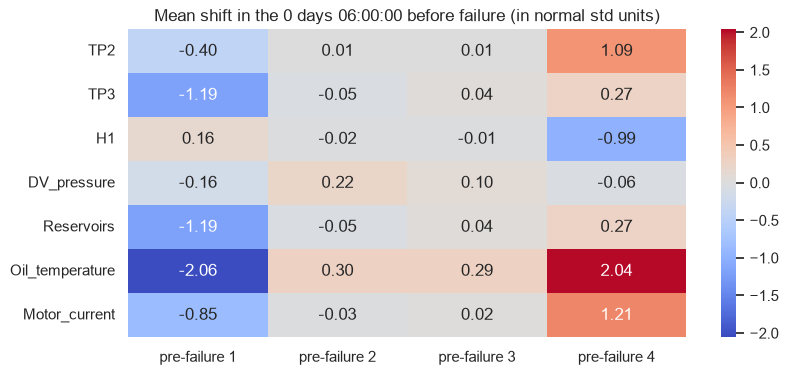

In [19]:
# Compare each sensor's mean in the pre-failure window against normal operation,
# in units of the normal standard deviation.
normal = df[(df["is_failure"] == 0) & (df["fail_within_h"] == 0)]
base_mean, base_std = normal[ANALOG].mean(), normal[ANALOG].std()

rows = {}
for i, (s, e) in enumerate(failures, 1):
    pre = df.loc[s - HORIZON : s, ANALOG].mean()
    rows[f"pre-failure {i}"] = (pre - base_mean) / base_std

shift = pd.DataFrame(rows)
display(shift.round(2))

plt.figure(figsize=(9, 4))
sns.heatmap(shift, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Mean shift in the {HORIZON} before failure (in normal std units)")
plt.show()

## 8. Notes (fill these in as you explore)

- Sampling interval: ...
- Biggest gaps / machine-off periods: ...
- Sensors that react before failures: ...
- Do all 4 failures look alike? ...
- Is the lead time long enough to be useful? ...

## 9. Save outputs

In [20]:
df.to_parquet(PROC_DIR / "metropt3_labeled.parquet")
print("Saved:", PROC_DIR / "metropt3_labeled.parquet")
print("Saved:", PROC_DIR / "failures.json")

Saved: ..\data\processed\metropt3_labeled.parquet
Saved: ..\data\processed\failures.json
